### ❤️ Heart Disease Prediction using Machine Learning

####  Importing Required Libraries

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#### Loading the Dataset

In [139]:
df = pd.read_csv("heart.csv")

#### Dataset Overview

In [140]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


#### Exploratory Data Analysis (EDA)

In [141]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [142]:
df.shape

(918, 12)

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Statistical Summary

In [144]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


#### Missing Value Analysis

In [145]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [146]:
df.duplicated().sum()

np.int64(0)

#### Heart Disease Distribution

Text(0.5, 1.0, 'Heart Disease Distribution')

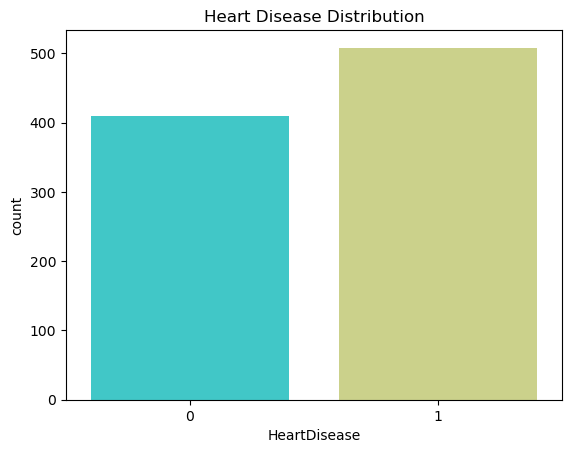

In [147]:
sns.countplot(data=df,x="HeartDisease",palette='rainbow')
plt.title("Heart Disease Distribution")

#### Heart Disease Distribution by Gender

Text(0.5, 1.0, 'Heart Disease Distribution by Gender')

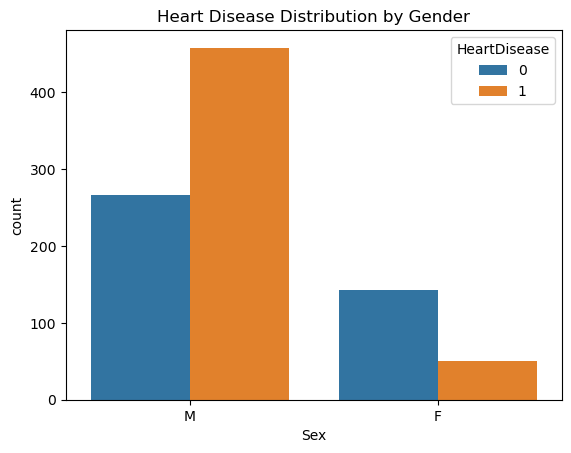

In [148]:
sns.countplot(x = df['Sex'],hue = df['HeartDisease'])
plt.title("Heart Disease Distribution by Gender")

#### Heart Disease by Chest Pain Type

Text(0.5, 1.0, 'Heart Disease by Chest Pain Type')

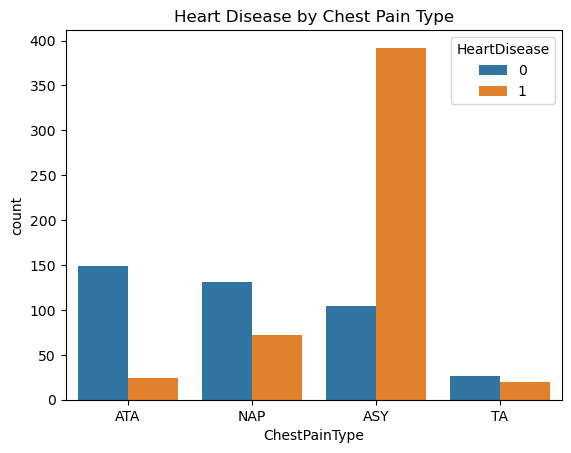

In [149]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])
plt.title("Heart Disease by Chest Pain Type")

#### Cholesterol Distribution by Heart Disease

Text(0.5, 1.0, 'Cholesterol Distribution by Heart Disease')

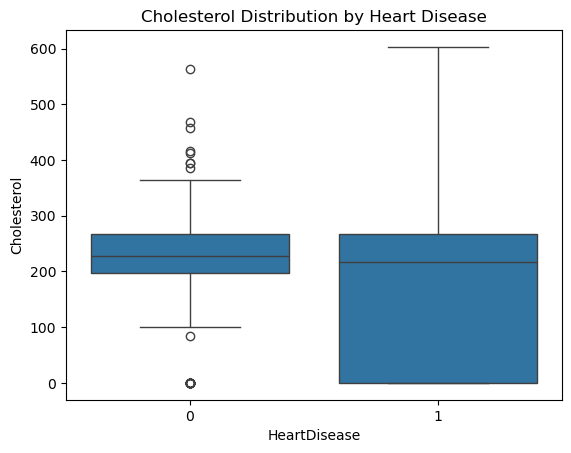

In [150]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)
plt.title("Cholesterol Distribution by Heart Disease")

#### Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

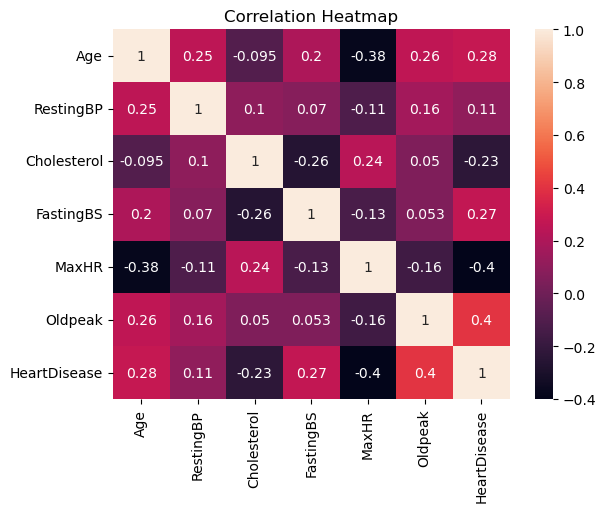

In [151]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")

### Feature Engineering

#### One-Hot Encoding

In [152]:
df_encode = pd.get_dummies(df,drop_first=True)

In [153]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [154]:
df_encode = df_encode.astype(int)

In [155]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


#### Selecting Features and Target Variable

In [156]:
x = df_encode.drop('HeartDisease',axis=1)
y = df_encode['HeartDisease']

#### Train-Test Split

In [157]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#### Feature Scaling

In [158]:
scaler = StandardScaler()
x_train_scal = scaler.fit_transform(x_train)
x_test_scal = scaler.fit_transform(x_test)

#### Model Training – Support Vector Machine (SVM)

In [159]:
model = {
    'Logistic Regression' : LogisticRegression(),
    'KNN' : KNeighborsClassifier(),
    'Naive Byes' : GaussianNB(),
    'Decision Tree' : DecisionTreeClassifier(),
    'SVM' : SVC()
}

In [160]:
result = []

In [161]:
for name,model in model.items():
    model.fit(x_train_scal,y_train)
    y_pred = model.predict(x_test_scal)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model':name,
        'Accuracy' : round(acc,4),
        'f1 score' : round(f1,4)
    })

In [162]:
result_df = pd.DataFrame(result)
result_df

,model,Accuracy,f1 score
0,Logistic Regression,0.8641,0.8804
1,KNN,0.8587,0.8750
2,Naive Byes,0.8696,0.8857
3,Decision Tree,0.7935,0.8208
4,SVM,0.8804,0.8972


#### Model Evaluation

In [163]:
import joblib

joblib.dump(model, 'SVM_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(x.columns.tolist(), 'column.pkl')

['column.pkl']

### Conclusion

In this project, a Heart Disease Prediction System was developed using Machine Learning techniques. The dataset was analyzed through Exploratory Data Analysis (EDA) to understand the relationships between patient health attributes and heart disease. Categorical features were converted using One-Hot Encoding, and numerical features were standardized using StandardScaler to prepare the data for model training.

A Support Vector Machine (SVM) classifier was trained and evaluated to predict the likelihood of heart disease based on patient health information. The trained model, along with the scaler and feature columns, was saved using Joblib for deployment.

Finally, the model was integrated into a Streamlit web application, allowing users to enter patient details through an interactive interface and receive real-time heart disease predictions. This project demonstrates the complete Machine Learning workflow, including data preprocessing, model development, evaluation, serialization, and deployment.